# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SaorsaNN_CPU as nnm
from matplotlib import animation

# Deterministic Seeding

In [2]:
def set_seed(seed: int):
    np.random.seed(seed) # change global seed for weight initialization

# Two Moons generator

In [3]:
def make_moons(n_samples=1000, noise=0.15, seed=0):
    rng = np.random.default_rng(seed)

    # split samples into 2 classes
    n1 = n_samples // 2
    n2 = n_samples - n1

    # 1st moon/half circle
    t1 = rng.uniform(0, np.pi, size=n1) # obtain angle (radians)
    x1 = np.c_[np.cos(t1), np.sin(t1)] # convert angles to coordinates (cartesian)

    # 2nd moon/half circle
    t2 = rng.uniform(0, np.pi, size=n2)
    x2 = np.c_[1 - np.cos(t2), 1 - np.sin(t2)] # shift and invert cartesian points

    X = np.vstack([x1, x2]) # stack points
    y = np.hstack([np.zeros(n1, dtype=int), np.ones(n2, dtype=int)]) # classify points (0: 1st moon, 1: 2nd moon)

    X += rng.normal(scale=noise, size=X.shape) # add noise to cartesian points

    idx = rng.permutation(n_samples) # shuffle point indicies
    return X[idx].astype(np.float32), y[idx] # retreive and return points

# Create Train and Validation Set

In [4]:
def train_val_split(X, y, val_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X)) # produce permutated indices for the length of X
    n_val = int(len(X) * val_ratio) # obtain number of values for the validation split (dafault validation set: 20%)
    val_idx = idx[:n_val] # get indices for the validation set
    tr_idx = idx[n_val:] # use the rest for training set
    return X[tr_idx], y[tr_idx], X[val_idx], y[val_idx]

# Build Model with specified weight initialization method

In [5]:
def build_model(weight_method):
    model = nnm.Model()

    model.add(nnm.Layer_Dense(2, 64, weight_method=weight_method))
    model.add(nnm.ReLU_Activation())

    model.add(nnm.Layer_Dense(64, 64, weight_method=weight_method))
    model.add(nnm.ReLU_Activation())

    model.add(nnm.Layer_Dense(64, 64, weight_method=weight_method))
    model.add(nnm.ReLU_Activation())

    model.add(nnm.Layer_Dense(64, 2, weight_method=weight_method))
    model.add(nnm.Activation_Softmax())

    model.set(
        loss=nnm.Loss_CategoricalCrossEntropy(),
        optimizer=nnm.Optimizer_Adam(learning_rate=0.001),
        accuracy=nnm.Accuracy_Categorical()
    )

    model.finalize()
    return model

# Run single training trial

In [6]:
def run_trial(X_tr, y_tr, X_val, y_val, *, seed, weight_method, epochs=200):
    set_seed(seed) 
    model = build_model(weight_method)

    model.train(X_tr, y_tr, epochs=epochs, batch_size=None, show_details=False) # ensure no printing

    # retrieve training metric data
    acc = np.array(model.metric_dict["accuracy"], dtype=float)
    loss = np.array(model.metric_dict["loss"], dtype=float)

    # Compute final validation accuracy
    y_pred = np.argmax(model.predict(X_val), axis=1)
    val_acc = np.mean(y_pred == y_val)

    return {
        "model": model,
        "acc": acc,
        "loss": loss,
        "val_acc": float(val_acc)
    }

# Study Driver

In [7]:
def run_study(X_tr, y_tr, X_val, y_val, inits, seeds, epochs=250):
    results = {init:{"acc":[], "loss":[], "val_acc":[], "models":[]} for init in inits}

    for init in inits:
        for s in seeds:
            out = run_trial(X_tr, y_tr, X_val, y_val, seed=s, weight_method=init, epochs=epochs)
            results[init]["acc"].append(out["acc"])
            results[init]["loss"].append(out["loss"])
            results[init]["val_acc"].append(out["val_acc"])
            results[init]["models"].append(out["model"])

        # stack to arrays: 
        # shape = (num_seeds, epochs)
        results[init]["acc"] = np.vstack(results[init]["acc"])
        results[init]["loss"] = np.vstack(results[init]["loss"])
        results[init]["val_acc"] = np.array(results[init]["val_acc"])

    return results

# Visuals for the Blog

## Plot A: Learning Curves (mean +- std)

In [8]:
def plot_mean_std_curves(results, key="acc", title="Accuracy vs Epoch"):
    plt.figure(figsize=(12,7))
    for init, data in results.items():
        arr = data[key] # shape (seeds, epochs)
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        x = np.arange(1, len(mean) + 1)

        plt.plot(x, mean, label=init)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy" if key == "acc" else "Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

## Plot B: Final validation accuracy distribution

In [9]:
def plot_final_val_acc(results):
    labels = list(results.keys())
    data = [results[k]["val_acc"] for k in labels]

    plt.figure(figsize=(12,7))
    plt.boxplot(data, tick_labels=labels, showmeans=True)
    plt.ylabel("Validation Accuracy")
    plt.title("Final Validation Accuracy Distribution (accross seeds)")
    plt.grid(True, alpha=0.2)
    plt.show()

## Plot C: Decision Boundaries (one representative run per init)

In [10]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # grid
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    pred = np.argmax(model.predict(grid), axis=1).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, pred, alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=12)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

# Select representative model

In [11]:
def pick_median_model(results, init_key):
    accs = results[init_key]["val_acc"]
    models = results[init_key]["models"]
    idx = np.argsort(accs)[len(accs) // 2]
    return models[idx]

# Main Study Code

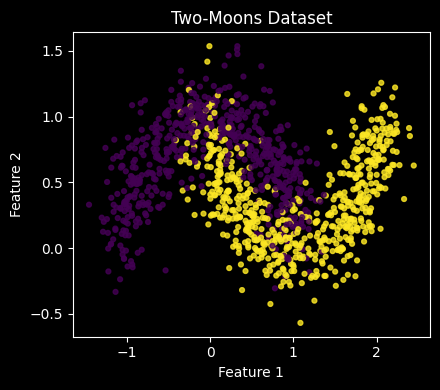

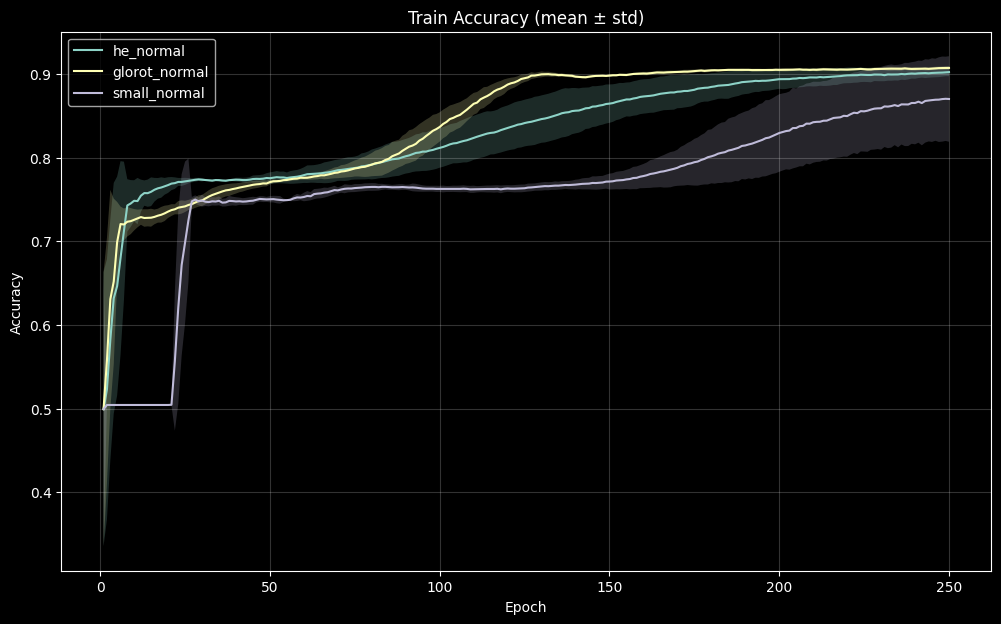

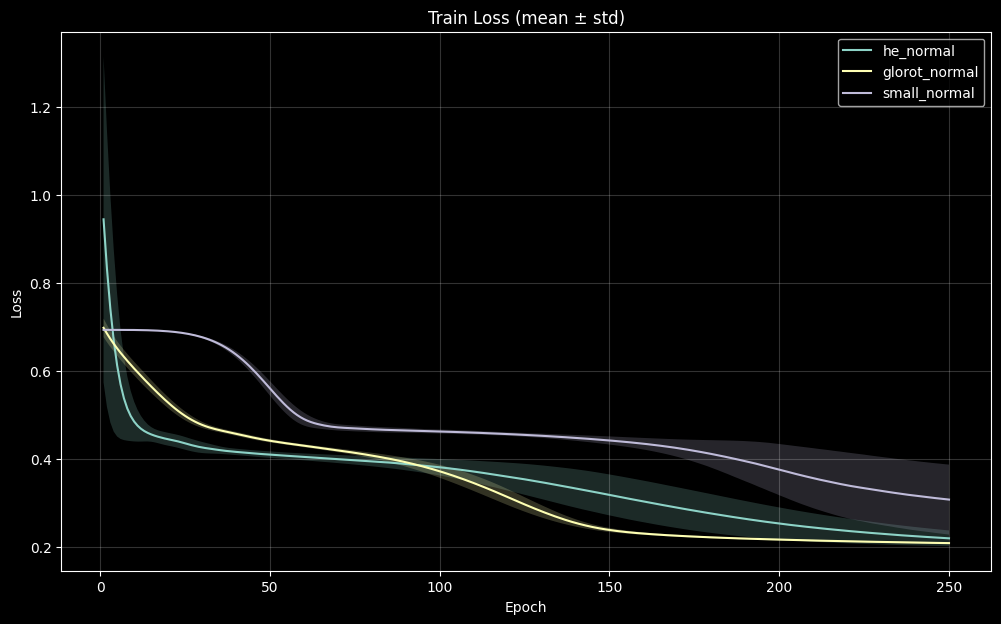

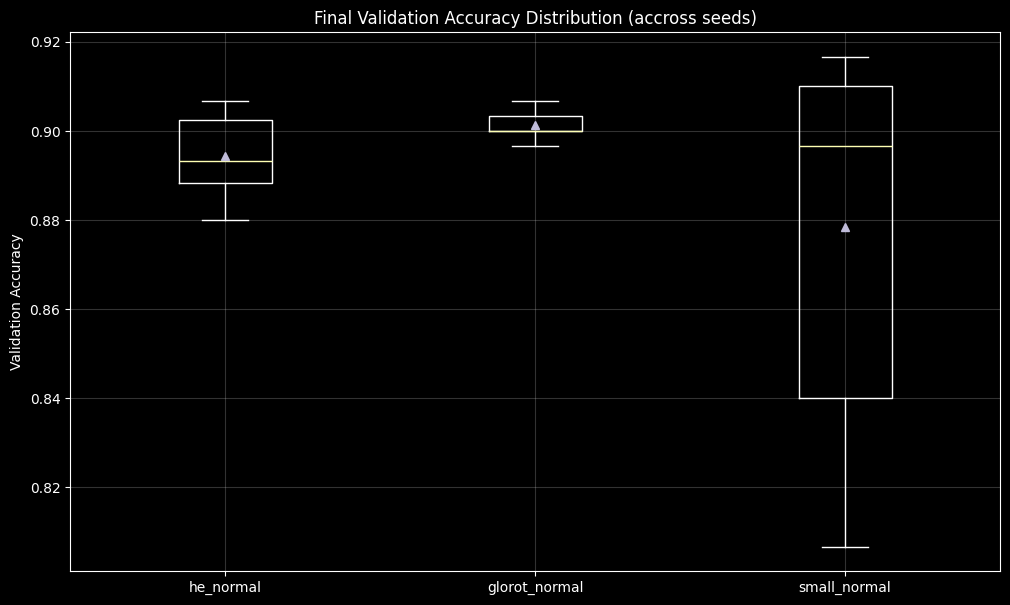

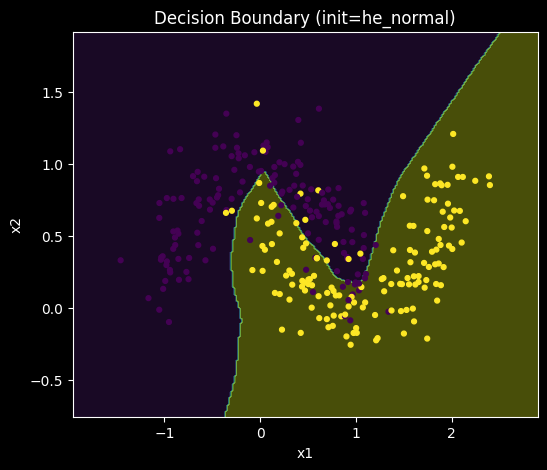

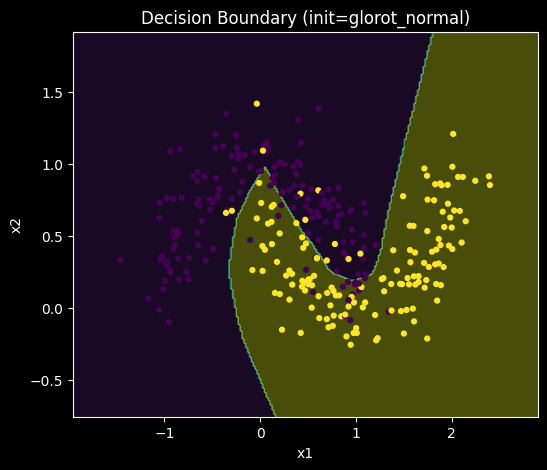

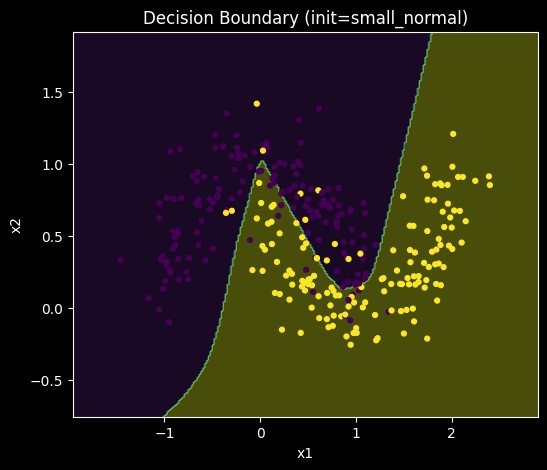

In [ ]:
%matplotlib inline

X, y = make_moons(n_samples=1200, noise=0.18, seed=1) # deterministic dataset produced to generate training and validation sets from
X_tr, y_tr, X_val, y_val = train_val_split(X, y, val_ratio=0.25, seed=1) # deterministic splitting of dataset

# plot dataset
plt.figure(figsize=(4.5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=12, alpha=0.8)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Moons Dataset")
plt.tight_layout()
plt.show()


# study parameters
inits = ["he_normal", "glorot_normal", "small_normal"]
seeds = list(range(10)) # 10 runs per init (different seeds for weight initialization)
epochs = 250

results = run_study(X_tr, y_tr, X_val, y_val, inits=inits, seeds=seeds, epochs=epochs)

plot_mean_std_curves(results, key="acc", title="Train Accuracy (mean ± std)")
plot_mean_std_curves(results, key="loss", title="Train Loss (mean ± std)")
plot_final_val_acc(results)

# decision boundaries
for init in inits:
    m = pick_median_model(results, init)
    plot_decision_boundary(m, X_val, y_val, title=f"Decision Boundary (init={init})")

# Save and/or Plot weight training (he_normal)

In [ ]:
%matplotlib widget

m = pick_median_model(results, "he_normal")
viz_obj = m.plot_training(fig_title=f"he_normal Training Plot", key="weights", input_layer_aspect="10.0")
anim = animation.FuncAnimation(viz_obj.fig, viz_obj.animate_training, frames=viz_obj.num_frames, interval=400)
#plt.show()
anim.save("he_normal.mp4", writer='ffmpeg', fps=20)

In [14]:
#anim.event_source.stop()

# Save and/or Plot weight training (glorot_normal)

In [ ]:
%matplotlib widget

m = pick_median_model(results, "glorot_normal")
viz_obj = m.plot_training(fig_title=f"glorot_normal Training Plot", key="weights", input_layer_aspect="10.0")
anim = animation.FuncAnimation(viz_obj.fig, viz_obj.animate_training, frames=viz_obj.num_frames, interval=400)
#plt.show()
anim.save("glorot_normal.mp4", writer='ffmpeg', fps=20)

In [16]:
#anim.event_source.stop()

# Save and/or Plot weight training (small_normal)

In [ ]:
%matplotlib widget

m = pick_median_model(results, "small_normal")
viz_obj = m.plot_training(fig_title=f"small_normal Training Plot", key="weights", input_layer_aspect="10.0")
anim = animation.FuncAnimation(viz_obj.fig, viz_obj.animate_training, frames=viz_obj.num_frames, interval=400, blit=True)
#plt.show()
anim.save("small_normal.mp4", writer='ffmpeg', fps=20)

In [ ]:
#anim.event_source.stop()